# Phase: Best ML Model — CatBoost / LightGBM Multiclass + Recall Optimization (Next 3 Hours)

**Goal:** Train a stronger multiclass model than Logistic Regression for forecasting the **next 3-hour block** collision risk class (0 / 1 / 2+), and apply **recall-focused threshold tuning** for the **High-risk class (Class 2)**.

**Input:** `processed_data/supervised_hood_3h_multiclass.csv`  
**Outputs (saved to `processed_data/`):**
- `best_ml_model.joblib` (LightGBM) **or** `best_ml_catboost.cbm` (CatBoost)
- `best_ml_features.txt`
- `best_ml_tau.txt`
- `best_ml_summary.csv`

> Recommended: Run **CatBoost first** (handles categorical HOOD cleanly, no scaling needed).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score
import matplotlib.pyplot as plt

import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

# Optional: if you want to reuse selected features from the previous phase
SEL_FEATURES_PATH = DATA_DIR / "logreg_selected_top25_features.txt" 

# Outputs
OUT_SUMMARY = MODEL_DIR / "best_ml_summary.csv"


In [2]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h", "HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))


Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [3]:
# --- Time-based split (same as earlier) ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

# Build X/y
y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class", "y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as a model feature (we already have time-derived features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [4]:
# --- Optionally use a selected feature list (keeps training faster & more interpretable) ---
use_selected_features = False  # set True if you want to use the top25 list file

if use_selected_features and SEL_FEATURES_PATH.exists():
    with open(SEL_FEATURES_PATH, "r") as f:
        sel = [line.strip() for line in f if line.strip()]
    # Keep only features that exist
    sel = [c for c in sel if c in X_train.columns]
    if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in sel:
        sel.append("HOOD_158_CODE")
    X_train = X_train[sel].copy()
    X_val   = X_val[sel].copy()
    X_test  = X_test[sel].copy()
    print("Using selected features:", len(sel))
else:
    sel = list(X_train.columns)
    print("Using all features:", len(sel))

# Identify categorical columns
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))


Using all features: 47
Categorical: ['HOOD_158_CODE']
Numeric count: 46


In [5]:
# --- Evaluation helpers ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
    return {
        "recall_0": rec[0], "recall_1": rec[1], "recall_2": rec[2],
        "macro_recall": macro_rec, "recall_high": rec_high, "precision_high": prec_high
    }

def apply_two_thresholds(proba, tau1, tau2):
    """
    Decision rule:
      if P2 >= tau2 -> 2
      elif P1 >= tau1 -> 1
      else -> 0
    """
    p1 = proba[:, 1]
    p2 = proba[:, 2]
    pred = np.zeros(len(p1), dtype=int)
    pred[p1 >= tau1] = 1
    pred[p2 >= tau2] = 2  # overwrite -> class 2 wins
    return pred

def tune_two_thresholds(proba_val, y_val,
                        tau1_grid=np.linspace(0.20, 0.70, 11),
                        tau2_grid=np.linspace(0.05, 0.40, 15),
                        min_recall_1=0.25,
                        max_pred2_rate=0.15):
    rows = []
    for tau1 in tau1_grid:
        for tau2 in tau2_grid:
            pred = apply_two_thresholds(proba_val, tau1, tau2)
            rec = recall_score(y_val, pred, labels=[0,1,2], average=None, zero_division=0)
            macro = recall_score(y_val, pred, average="macro", zero_division=0)
            rec_high = recall_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            prec_high = precision_score((y_val==2).astype(int), (pred==2).astype(int), zero_division=0)
            pred2_rate = float((pred==2).mean())
            rows.append((tau1, tau2, macro, rec[1], rec_high, prec_high, pred2_rate))
    df = pd.DataFrame(rows, columns=["tau1","tau2","macro_recall","recall_1","recall_2","precision_2","pred2_rate"])
    feasible = df[(df["recall_1"] >= min_recall_1) & (df["pred2_rate"] <= max_pred2_rate)]
    best = (feasible if len(feasible) else df).sort_values(
        ["macro_recall","recall_2","precision_2"], ascending=False
    ).iloc[0]
    return float(best["tau1"]), float(best["tau2"]), df


In [6]:
# --- Class weights (balanced) ---
# Weights help the rare class (2) get more attention.
class_counts = y_train.value_counts().sort_index()
total = class_counts.sum()
# sklearn-style "balanced": n_samples / (n_classes * count)
weights = (total / (3 * class_counts)).to_dict()
print("Class counts (train):")
print(class_counts)
print("Class weights:")
print(weights)


Class counts (train):
y_class
0    823183
1     86350
2     13187
Name: count, dtype: int64
Class weights:
{0: 0.373639073369267, 1: 3.561937849835939, 2: 23.323980688051364}


## A) CatBoost Multiclass (recommended)
CatBoost can directly use categorical features without one-hot encoding and typically performs very well on tabular data.


0:	learn: 0.6798079	test: 0.6796923	best: 0.6796923 (0)	total: 519ms	remaining: 25m 55s
200:	learn: 0.4103135	test: 0.4082223	best: 0.4082223 (200)	total: 1m 39s	remaining: 23m 10s
400:	learn: 0.4070209	test: 0.4066786	best: 0.4066786 (400)	total: 3m 33s	remaining: 23m 4s
600:	learn: 0.4048187	test: 0.4063713	best: 0.4063563 (575)	total: 5m 33s	remaining: 22m 12s
800:	learn: 0.4027874	test: 0.4062419	best: 0.4062419 (800)	total: 7m 43s	remaining: 21m 13s
1000:	learn: 0.4009752	test: 0.4062719	best: 0.4062196 (816)	total: 9m 56s	remaining: 19m 50s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.4062196027
bestIteration = 816

Shrink model to first 817 iterations.

=== CatBoost Argmax - Val ===
Per-class recall [0,1,2]: [0.9583 0.1367 0.153 ]
Macro recall: 0.416
High-risk recall: 0.153
High-risk precision: 0.1773

               precision    recall  f1-score   support

           0     0.9124    0.9583    0.9348    204791
           1     0.2605    0.1367    0.1793  

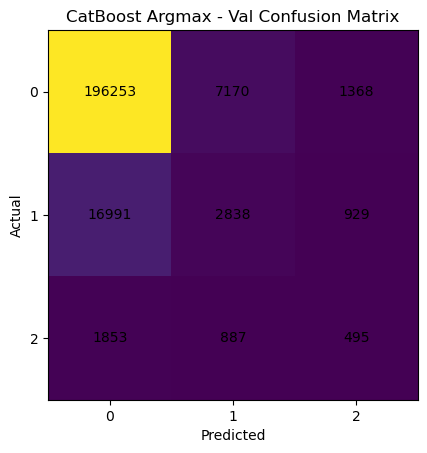


=== CatBoost Argmax - Test ===
Per-class recall [0,1,2]: [0.9488 0.1581 0.2014]
Macro recall: 0.4361
High-risk recall: 0.2014
High-risk precision: 0.1738

               precision    recall  f1-score   support

           0     0.9148    0.9488    0.9315    207818
           1     0.2592    0.1581    0.1964     21189
           2     0.1738    0.2014    0.1866      3411

    accuracy                         0.8658    232418
   macro avg     0.4493    0.4361    0.4382    232418
weighted avg     0.8442    0.8658    0.8536    232418



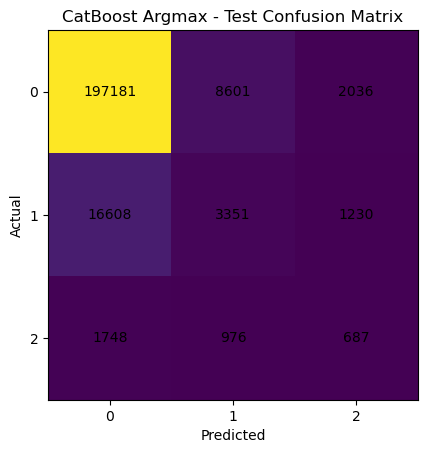

Chosen thresholds (CatBoost): {'tau1': 0.25, 'tau2': 0.125}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
18,0.25,0.125,0.545032,0.307785,0.629057,0.064887,0.137081
3,0.20,0.125,0.545003,0.433231,0.629057,0.064887,0.137081
17,0.25,0.100,0.542405,0.232970,0.696754,0.055091,0.178832
2,0.20,0.100,0.542267,0.357356,0.696754,0.055091,0.178832
4,0.20,0.150,0.541152,0.492148,0.558578,0.074225,0.106410
19,0.25,0.150,0.541135,0.366365,0.558578,0.074225,0.106410
5,0.20,0.175,0.540550,0.544128,0.504791,0.085034,0.083939
20,0.25,0.175,0.540458,0.418056,0.504791,0.085034,0.083939
6,0.20,0.200,0.536258,0.580403,0.455641,0.094748,0.067999
21,0.25,0.200,0.536115,0.454138,0.455641,0.094748,0.067999



=== CatBoost Two-Threshold (tau1=0.25, tau2=0.12) - Test ===
Per-class recall [0,1,2]: [0.6726 0.3022 0.6752]
Macro recall: 0.55
High-risk recall: 0.6752
High-risk precision: 0.065

               precision    recall  f1-score   support

           0     0.9524    0.6726    0.7884    207818
           1     0.1274    0.3022    0.1793     21189
           2     0.0650    0.6752    0.1187      3411

    accuracy                         0.6389    232418
   macro avg     0.3816    0.5500    0.3621    232418
weighted avg     0.8642    0.6389    0.7231    232418



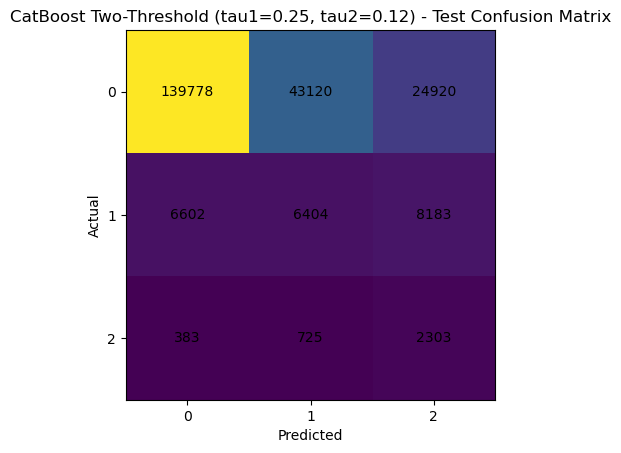

Saved: ../models/best_ml_catboost_thresholds.json
Saved: ../models/best_ml_catboost.cbm
Saved: ../models/best_ml_catboost_thresholds.json


In [11]:
# --- CatBoost training ---
import json


try:
    from catboost import CatBoostClassifier
    catboost_available = True
except Exception as e:
    catboost_available = False
    print("CatBoost not available:", e)

results = []

if catboost_available:
    # Identify categorical feature indices for CatBoost
    # CatBoost expects column indices in the training dataframe
    cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

    cb = CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        #eval_metric="MultiClass",
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=10.0,
        random_seed=42,
        verbose=200,
        auto_class_weights="SqrtBalanced",   # IMPORTANT: better than extreme manual weights
        od_type="Iter",
        od_wait=300
    )

    cb.fit(
        X_train, y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    # Argmax evaluation
    pred_val_cb = cb.predict(X_val).reshape(-1).astype(int)
    metrics_val = eval_multiclass(y_val, pred_val_cb, name="CatBoost Argmax - Val")

    pred_test_cb = cb.predict(X_test).reshape(-1).astype(int)
    metrics_test = eval_multiclass(y_test, pred_test_cb, name="CatBoost Argmax - Test")

    # Threshold tuning (High-risk)
    # Two-threshold tuning (Val) -> apply to Test
    proba_val_cb = cb.predict_proba(X_val)
    tau1_cb, tau2_cb, grid_cb = tune_two_thresholds(proba_val_cb, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
    print("Chosen thresholds (CatBoost):", {"tau1": tau1_cb, "tau2": tau2_cb})
    display(grid_cb.sort_values(["macro_recall","recall_2","precision_2"], ascending=False).head(10))

    pred_test_cb_thr = apply_two_thresholds(cb.predict_proba(X_test), tau1_cb, tau2_cb)
    metrics_test_thr = eval_multiclass(y_test, pred_test_cb_thr, name=f"CatBoost Two-Threshold (tau1={tau1_cb:.2f}, tau2={tau2_cb:.2f}) - Test")

    # Save CatBoost model
    OUT_CB = MODEL_DIR / "best_ml_catboost.cbm"
    cb.save_model(str(OUT_CB))

    # Save tau + features
    OUT_CB_THR = MODEL_DIR / "best_ml_catboost_thresholds.json"
    with open(OUT_CB_THR, "w") as f:
        json.dump({"tau1": tau1_cb, "tau2": tau2_cb}, f, indent=2)
    print("Saved:", OUT_CB_THR)

    OUT_CB_FEATS = MODEL_DIR / "best_ml_catboost_features.txt"
    with open(OUT_CB_FEATS, "w") as f:
        for c in X_train.columns:
            f.write(c + "\n")

    results.append({
    "model": "CatBoost Argmax", **metrics_test
    })
    results.append({
    "model": f"CatBoost Two-Threshold (tau1={tau1_cb:.2f}, tau2={tau2_cb:.2f})", **metrics_test_thr
    })

    OUT_CB_THR = MODEL_DIR / "best_ml_catboost_thresholds.json"
    with open(OUT_CB_THR, "w") as f:
        json.dump({"tau1": float(tau1_cb), "tau2": float(tau2_cb)}, f, indent=2)

    print("Saved:", OUT_CB)
    print("Saved:", OUT_CB_THR)


## B) LightGBM Multiclass (optional alternative)

LightGBM usually needs categorical features encoded. We use one-hot encoding via a preprocessing pipeline.  
No scaling is required for tree models, but keeping numeric imputation is important.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2806
[LightGBM] [Info] Number of data points in the train set: 922720, number of used features: 204
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

=== LightGBM Argmax - Val ===
Per-class recall [0,1,2]: [0.7141 0.5058 0.2553]
Macro recall: 0.4917
High-risk recall: 0.2553
High-risk precision: 0.0881

               precision    recall  f1-score   support

           0     0.9454    0.7141    0.8136    204791
           1     0.1622    0.5058    0.2457     20758
           2     0.0881    0.2553    0.1310      3235

    accuracy                         0.6887    228784
   macro avg     0.3986    0.4917    0.3968    228784
w

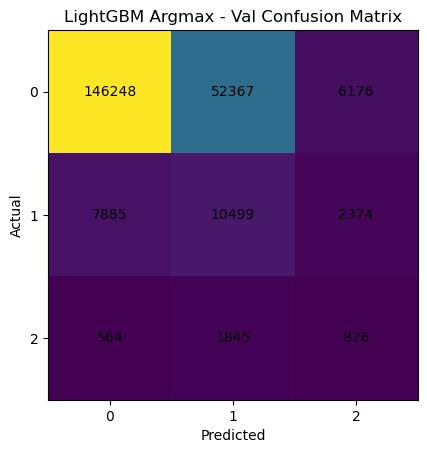


=== LightGBM Argmax - Test ===
Per-class recall [0,1,2]: [0.6867 0.5182 0.3363]
Macro recall: 0.5137
High-risk recall: 0.3363
High-risk precision: 0.0955

               precision    recall  f1-score   support

           0     0.9492    0.6867    0.7969    207818
           1     0.1567    0.5182    0.2407     21189
           2     0.0955    0.3363    0.1487      3411

    accuracy                         0.6662    232418
   macro avg     0.4005    0.5137    0.3954    232418
weighted avg     0.8644    0.6662    0.7367    232418



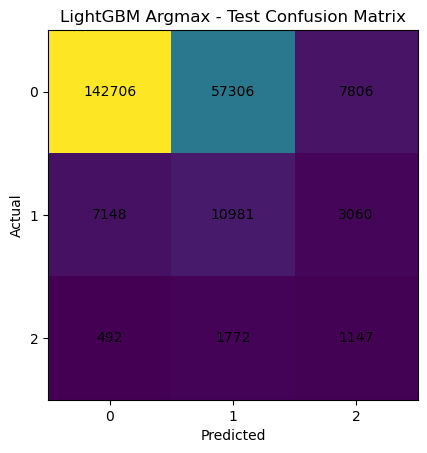

Chosen thresholds (LightGBM): {'tau1': 0.4, 'tau2': 0.22500000000000003}


,tau1,tau2,macro_recall,recall_1,recall_2,precision_2,pred2_rate
66,0.40,0.200,0.523674,0.383418,0.576507,0.054080,0.150736
64,0.40,0.150,0.523288,0.305858,0.665224,0.045438,0.207012
65,0.40,0.175,0.522937,0.347095,0.616074,0.049393,0.176367
67,0.40,0.225,0.522739,0.415792,0.536940,0.058716,0.129305
79,0.45,0.150,0.522468,0.233404,0.665224,0.045438,0.207012
81,0.45,0.200,0.521964,0.299403,0.576507,0.054080,0.150736
68,0.40,0.250,0.521868,0.445563,0.501082,0.063649,0.111319
80,0.45,0.175,0.521743,0.268860,0.616074,0.049393,0.176367
63,0.40,0.125,0.520913,0.260719,0.712828,0.041176,0.244785
78,0.45,0.125,0.520834,0.196647,0.712828,0.041176,0.244785



=== LightGBM Two-Threshold (tau1=0.40, tau2=0.23) - Test ===
Per-class recall [0,1,2]: [0.5887 0.3913 0.6203]
Macro recall: 0.5334
High-risk recall: 0.6203
High-risk precision: 0.0607

               precision    recall  f1-score   support

           0     0.9568    0.5887    0.7289    207818
           1     0.1190    0.3913    0.1825     21189
           2     0.0607    0.6203    0.1105      3411

    accuracy                         0.5711    232418
   macro avg     0.3788    0.5334    0.3406    232418
weighted avg     0.8673    0.5711    0.6700    232418



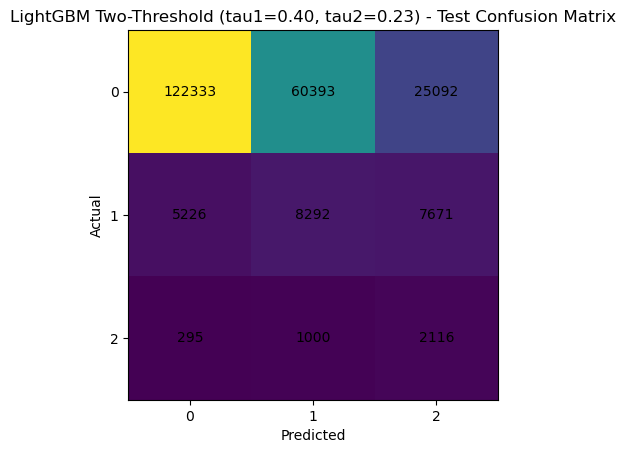

Saved: ../models/best_ml_lightgbm_thresholds.json
Saved: ../models/best_ml_lightgbm.joblib
Saved: ../models/best_ml_lightgbm_thresholds.json
Saved: ../models/best_ml_lightgbm_features.txt


In [13]:
# --- LightGBM training ---
try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception as e:
    lgbm_available = False
    print("LightGBM not available:", e)

if lgbm_available:
    # Preprocess: impute numeric + one-hot categorical (NO scaler needed for trees)
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.impute import SimpleImputer

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess_lgbm = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop"
    )

    lgbm = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=1200,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=200,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        class_weight=weights,
        n_jobs=-1
    )
    

    lgbm_pipe = Pipeline(steps=[
        ("preprocess", preprocess_lgbm),
        ("model", lgbm)
    ])

    # Fit with early stopping using validation (LightGBM supports it via callbacks in recent versions)
    lgbm_pipe.fit(X_train, y_train)

    # Argmax evaluation
    pred_val_lgbm = lgbm_pipe.predict(X_val)
    metrics_val = eval_multiclass(y_val, pred_val_lgbm, name="LightGBM Argmax - Val")

    pred_test_lgbm = lgbm_pipe.predict(X_test)
    metrics_test = eval_multiclass(y_test, pred_test_lgbm, name="LightGBM Argmax - Test")

    # Threshold tuning (High-risk)
    proba_val_lgbm = lgbm_pipe.predict_proba(X_val)
    tau1_lg, tau2_lg, grid_lg = tune_two_thresholds(proba_val_lgbm, y_val, min_recall_1=0.25, max_pred2_rate=0.15)
    print("Chosen thresholds (LightGBM):", {"tau1": tau1_lg, "tau2": tau2_lg})
    display(grid_lg.sort_values(["macro_recall","recall_2","precision_2"], ascending=False).head(10))

    pred_test_lgbm_thr = apply_two_thresholds(lgbm_pipe.predict_proba(X_test), tau1_lg, tau2_lg)
    metrics_test_thr = eval_multiclass(y_test, pred_test_lgbm_thr, name=f"LightGBM Two-Threshold (tau1={tau1_lg:.2f}, tau2={tau2_lg:.2f}) - Test")

    # Save model
    OUT_LGBM = MODEL_DIR / "best_ml_lightgbm.joblib"
    joblib.dump(lgbm_pipe, OUT_LGBM)

    OUT_LGBM_THR = MODEL_DIR / "best_ml_lightgbm_thresholds.json"
    with open(OUT_LGBM_THR, "w") as f:
        json.dump({"tau1": tau1_lg, "tau2": tau2_lg}, f, indent=2)
    print("Saved:", OUT_LGBM_THR)

    OUT_LGBM_FEATS = MODEL_DIR / "best_ml_lightgbm_features.txt"
    with open(OUT_LGBM_FEATS, "w") as f:
        for c in X_train.columns:
            f.write(c + "\n")

    results.append({
    "model": "LightGBM Argmax", **metrics_test
    })
    results.append({
    "model": f"LightGBM Two-Threshold (tau1={tau1_lg:.2f}, tau2={tau2_lg:.2f})", **metrics_test_thr
    })

    print("Saved:", OUT_LGBM)
    print("Saved:", OUT_LGBM_THR)
    print("Saved:", OUT_LGBM_FEATS)


In [14]:
# --- Compare models (Test metrics summary) ---
summary = pd.DataFrame(results)
if len(summary):
    summary = summary[["model","macro_recall","recall_high","precision_high","recall_0","recall_1","recall_2"]]
    summary = summary.sort_values(["recall_high","macro_recall"], ascending=False)
    print(summary)
    summary.to_csv(OUT_SUMMARY, index=False)
    print("Saved:", OUT_SUMMARY)
else:
    print("No ML models ran (install catboost/lightgbm and rerun).")


                                           model  macro_recall  recall_high  \
1  CatBoost Two-Threshold (tau1=0.25, tau2=0.12)      0.550000     0.675169   
3  LightGBM Two-Threshold (tau1=0.40, tau2=0.23)      0.533445     0.620346   
2                                LightGBM Argmax      0.513731     0.336265   
0                                CatBoost Argmax      0.436124     0.201407   

   precision_high  recall_0  recall_1  recall_2  
1        0.065045  0.672598  0.302232  0.675169  
3        0.060667  0.588654  0.391335  0.620346  
2        0.095480  0.686687  0.518241  0.336265  
0        0.173792  0.948816  0.158148  0.201407  
Saved: ../models/best_ml_summary.csv
